# Clustering Jerárquico Aglomerativo (HAC)
## Dataset: Hotel Bookings

El **Clustering Jerárquico Aglomerativo** (HAC) agrupa observaciones similares construyendo
una jerarquía ascendente: cada observación comienza como su propio cluster y se van fusionando
los más parecidos hasta obtener un único árbol llamado **dendrograma**.

La clase `HAC` hereda de `NoSupervisado → AnalisisDatosExploratorio`, por lo que
expone todos los métodos de limpieza y transformación del EDA directamente sobre el objeto.

### Flujo de trabajo
```
mf.HAC(path, num)          # 1. Cargar datos
    ↓ métodos EDA heredados # 2. Limpiar y preparar
hac.ajustar()              # 3. Ajustar el modelo
hac.plot_*()               # 4. Visualizar resultados
```

## 1. Importación de librerías

In [1]:
import sys
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
import pckEDA as mf

%matplotlib inline
print('pckEDA cargado correctamente')
print('Clase HAC disponible:', mf.HAC)

pckEDA cargado correctamente
Clase HAC disponible: <class 'pckEDA.no_supervisado.hac.HAC'>


## 2. Carga de datos

`HAC` hereda de `AnalisisDatosExploratorio`, por lo que carga el CSV directamente.
- Modo `1`: separador coma, primera columna como índice.

In [2]:
hac = mf.HAC('../datasets/hotel_bookings.csv', 1, n_clusters=4, metodo='ward')

hac.mostrarTamaño()
hac.muestraTiposDeDatos()

Tamaño del DataFrame: (408, 20)
hotel                           object
is_canceled                      int64
lead_time                        int64
arrival_date_month              object
stays_in_weekend_nights          int64
                                ...   
customer_type                   object
adr                            float64
required_car_parking_spaces      int64
total_of_special_requests        int64
reservation_status              object
Length: 20, dtype: object


## 3. Preprocesamiento con métodos heredados del EDA

### 3.1 Codificación de variables categóricas

In [3]:
hac.codificarCategorica('hotel')
hac.codificarCategorica('arrival_date_month')
hac.codificarCategorica('assigned_room_type')
hac.codificarCategorica('deposit_type', mapeo={'No Deposit': 0, 'Non Refund': 1, 'Refundable': 2})
hac.codificarCategorica('customer_type')
hac.codificarCategorica('reservation_status')

Columna 'hotel' codificada con el mapeo:
  City Hotel → 0
  Resort Hotel → 1
Columna 'arrival_date_month' codificada con el mapeo:
  April → 0
  August → 1
  February → 2
  January → 3
  July → 4
  June → 5
  March → 6
  May → 7
Columna 'assigned_room_type' codificada con el mapeo:
  A → 0
  B → 1
  C → 2
  D → 3
  E → 4
  F → 5
  G → 6
  H → 7
  I → 8
  K → 9
Columna 'deposit_type' codificada con el mapeo:
  No Deposit → 0
  Non Refund → 1
  Refundable → 2
Columna 'customer_type' codificada con el mapeo:
  Contract → 0
  Group → 1
  Transient → 2
  Transient-Party → 3
Columna 'reservation_status' codificada con el mapeo:
  Canceled → 0
  Check-Out → 1
  No-Show → 2


### 3.2 Limpieza de nulos y duplicados

In [4]:
hac.eliminarDuplicados()
hac.eliminarNulos()

Se eliminaron 13 filas duplicadas. Total actual: 395 filas.
Valores nulos antes: 0 en 395 filas.
hotel                          0
is_canceled                    0
lead_time                      0
arrival_date_month             0
stays_in_weekend_nights        0
                              ..
customer_type                  0
adr                            0
required_car_parking_spaces    0
total_of_special_requests      0
reservation_status             0
Length: 20, dtype: int64
Valores nulos después: 0 en 395 filas.


### 3.3 Conservar solo columnas numéricas

In [5]:
hac.analisisNumerico()
print(f'Columnas para el modelo: {list(hac.df.columns)}')
print(f'Observaciones: {len(hac.df)}')

Columnas para el modelo: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'assigned_room_type', 'booking_changes', 'deposit_type', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status']
Observaciones: 395


## 4. Ajuste del modelo HAC

Con los datos ya limpios, se llama a `ajustar()` para entrenar el modelo.

In [6]:
hac.ajustar()

print(f'Método de enlace  : {hac.metodo}')
print(f'Número de clusters: {hac.n_clusters}')
print(f'Correlación cofenética: {hac.cophenet_corr:.4f}')
print()
import pandas as pd
print('Distribución de observaciones por cluster:')
print(pd.Series(hac.etiquetas).value_counts().sort_index())

Método de enlace  : ward
Número de clusters: 4
Correlación cofenética: 0.3613

Distribución de observaciones por cluster:
1    203
2      5
3      5
4    182
Name: count, dtype: int64


> **Correlación cofenética ≥ 0.70** → clustering aceptable. **≥ 0.80** → muy buena calidad.

## 5. Visualizaciones

### 5.1 Dendrograma

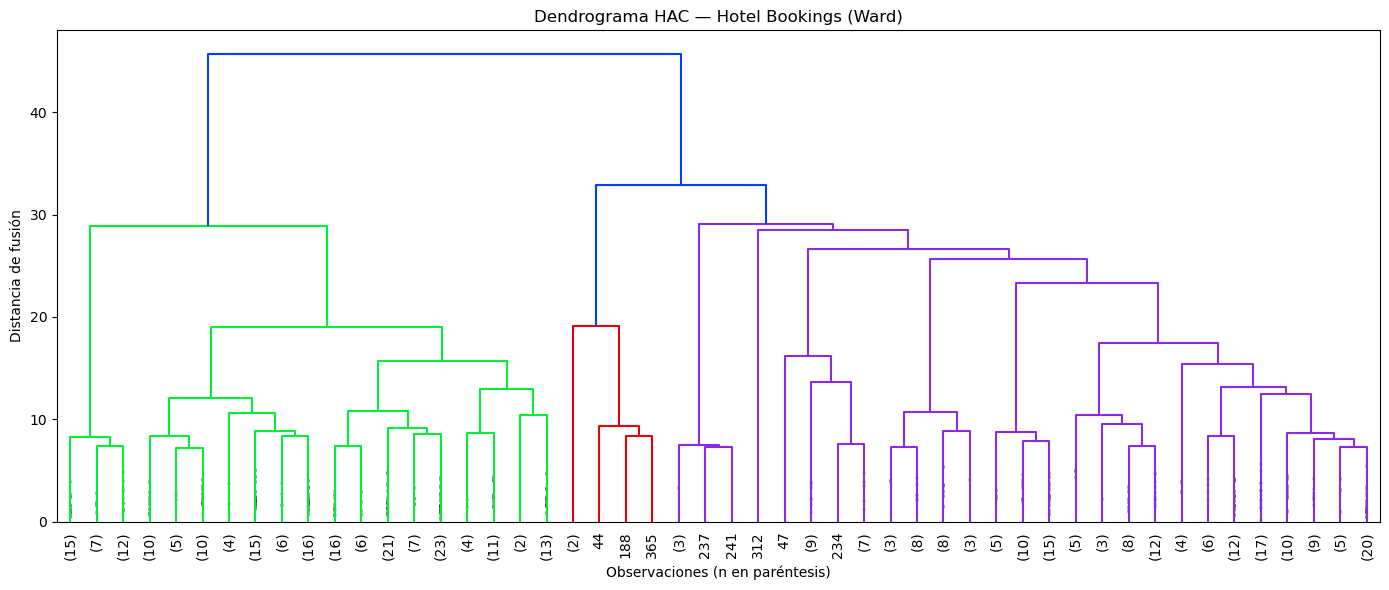

In [7]:
plt.figure(figsize=(14, 6))
hac.plot_dendrograma(max_hojas=50, titulo='Dendrograma HAC — Hotel Bookings (Ward)')
plt.tight_layout()
plt.show()

### 5.2 Mapa de calor — Perfil de clusters

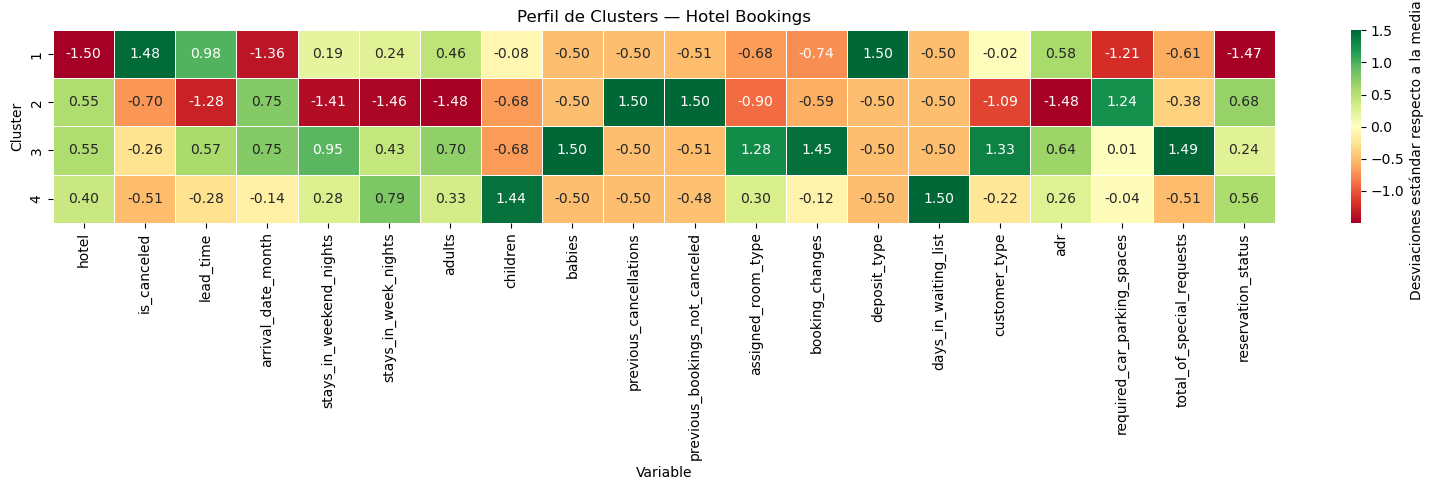

In [8]:
plt.figure(figsize=(16, 5))
hac.plot_mapa_calor(titulo='Perfil de Clusters — Hotel Bookings')
plt.tight_layout()
plt.show()

### 5.3 Distribución de observaciones por cluster

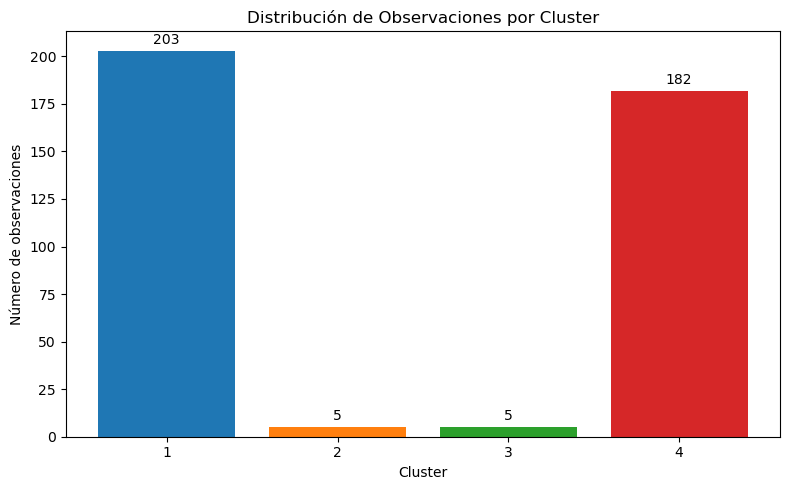

In [9]:
plt.figure(figsize=(8, 5))
hac.plot_distribucion(titulo='Distribución de Observaciones por Cluster')
plt.tight_layout()
plt.show()

### 5.4 Diagramas de dispersión por cluster

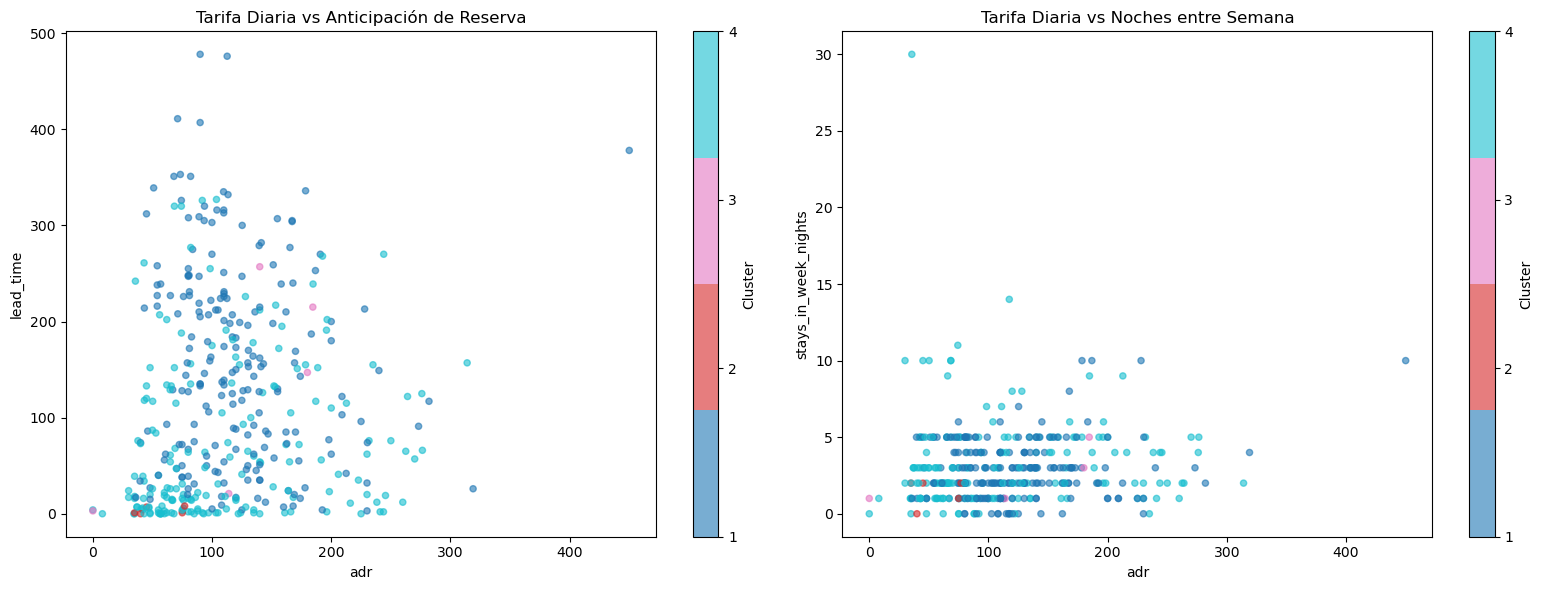

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
hac.plot_dispersion('adr', 'lead_time', titulo='Tarifa Diaria vs Anticipación de Reserva')

plt.sca(axes[1])
hac.plot_dispersion('adr', 'stays_in_week_nights', titulo='Tarifa Diaria vs Noches entre Semana')

plt.tight_layout()
plt.show()

### 5.5 Barras de centroides por cluster

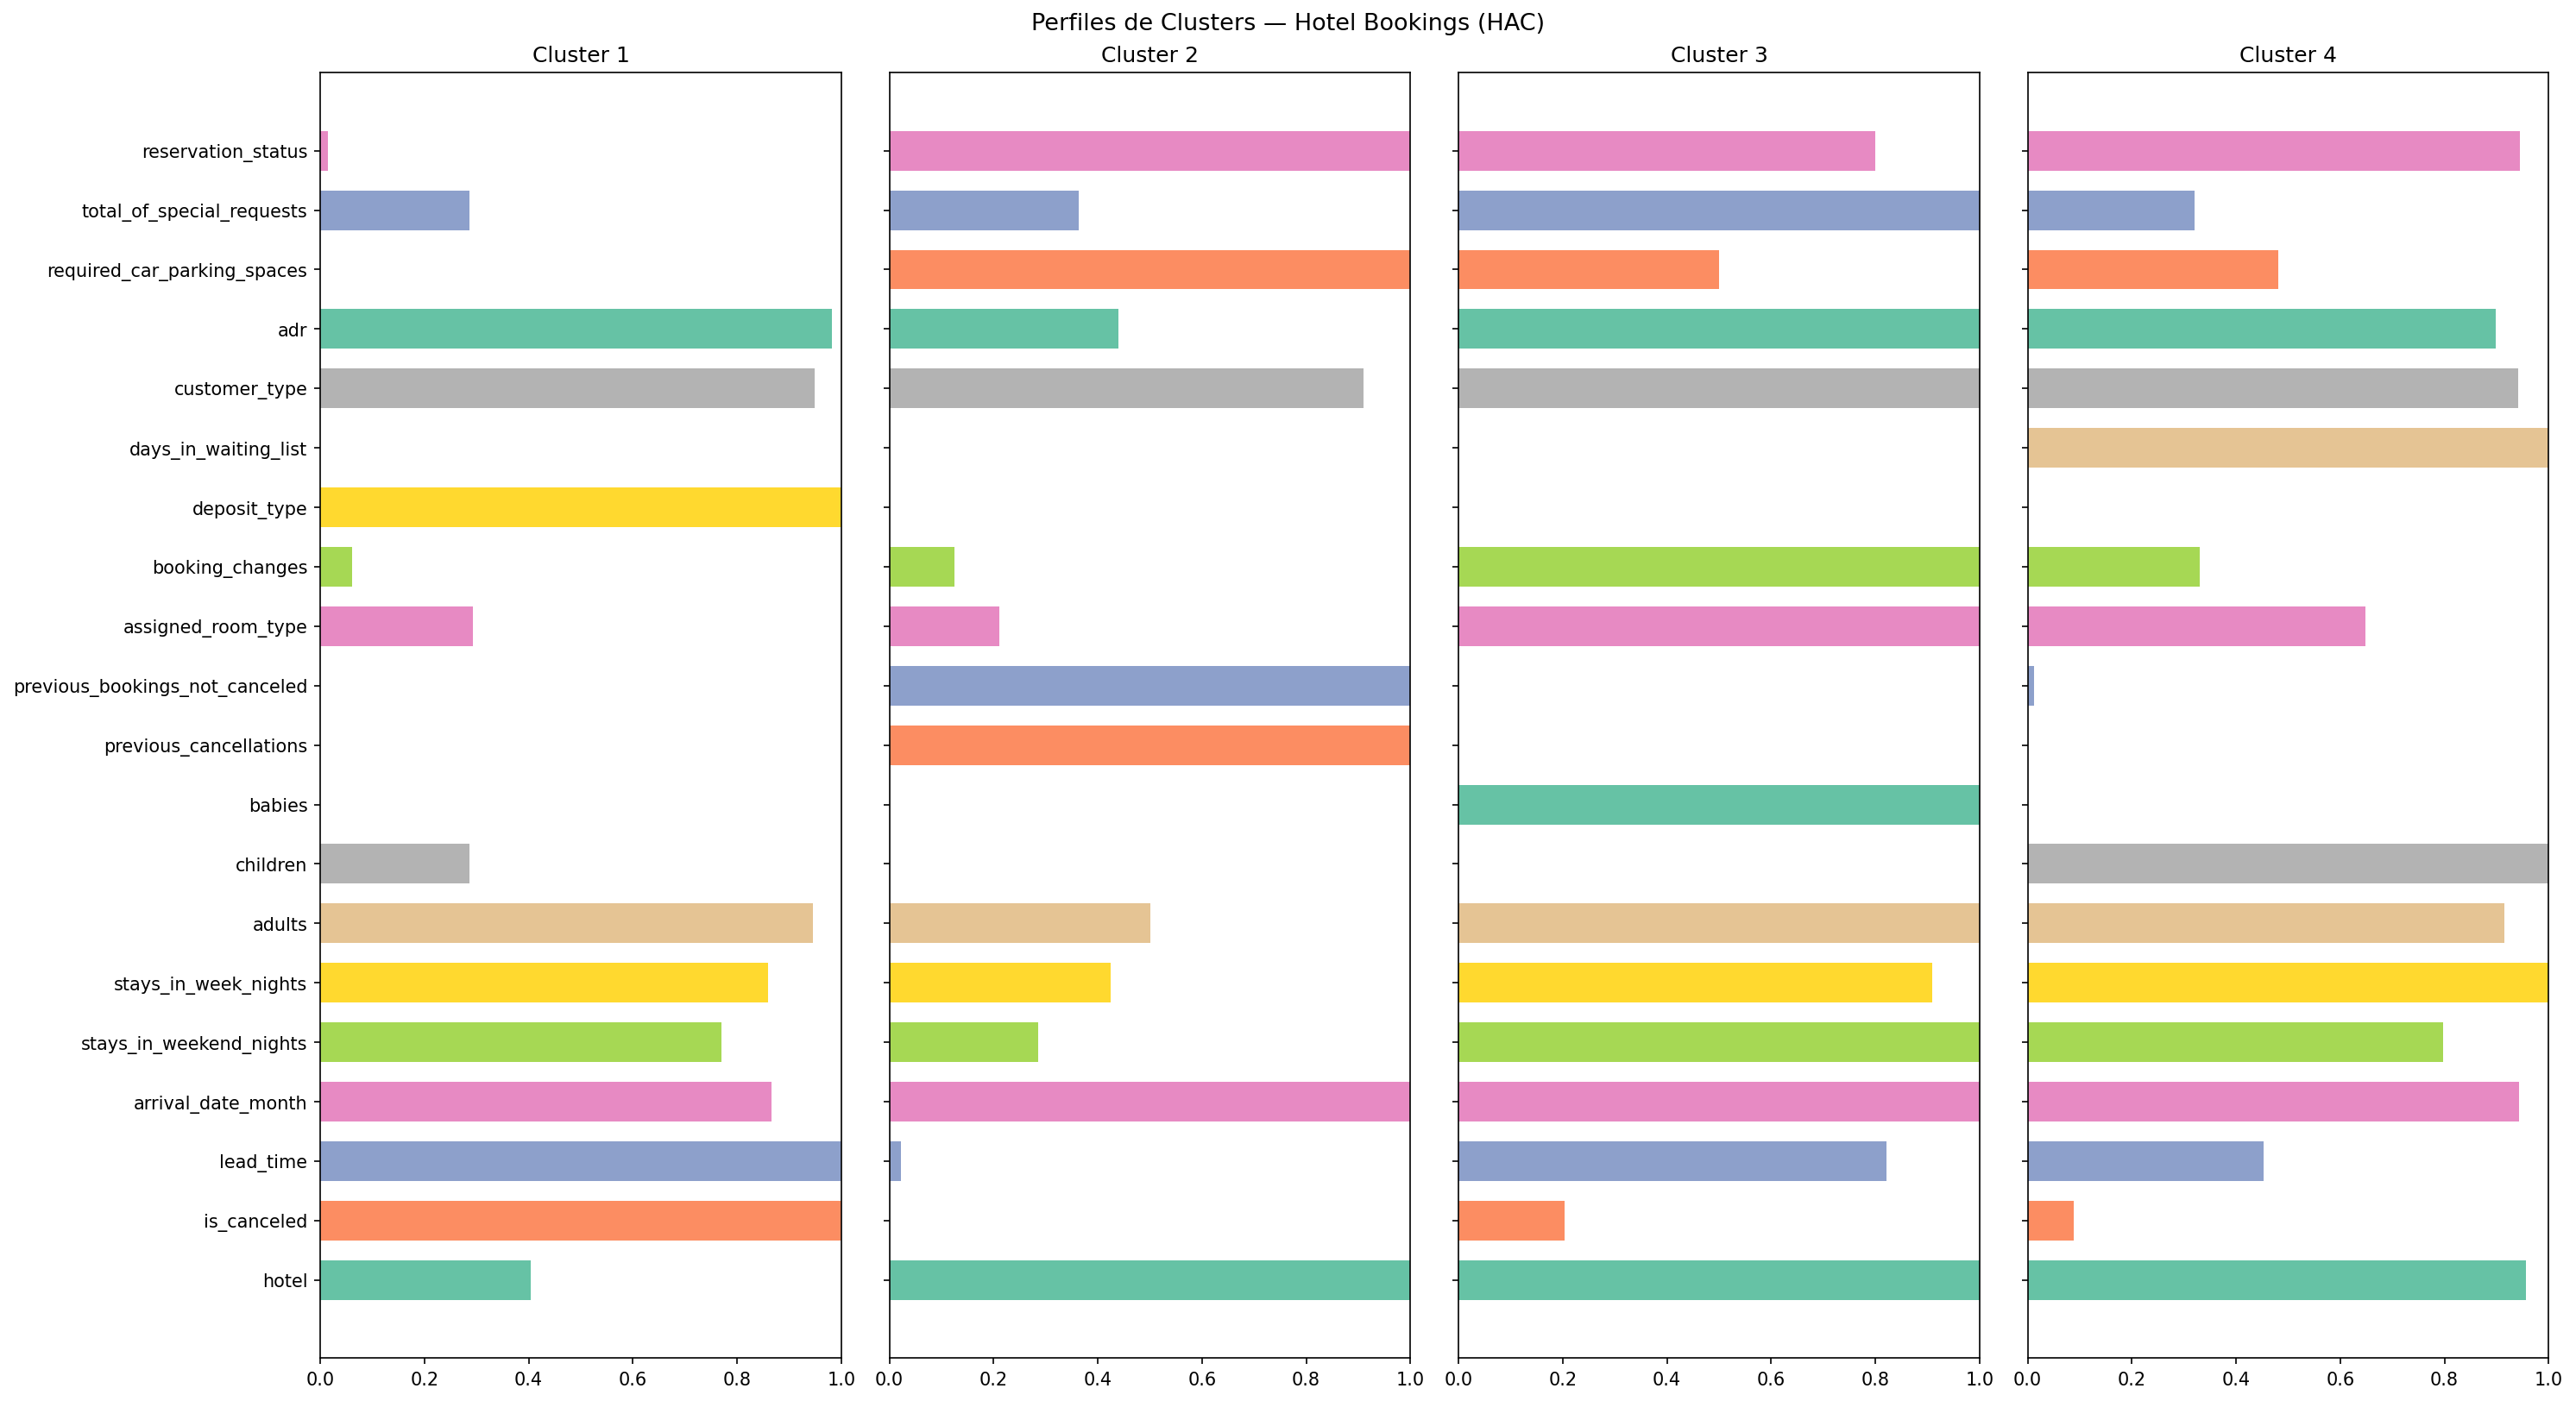

In [11]:
hac.plot_barras(
    titulo='Perfiles de Clusters — Hotel Bookings (HAC)',
    escala=True
)
plt.show()

### 5.6 Gráfico radar de clusters

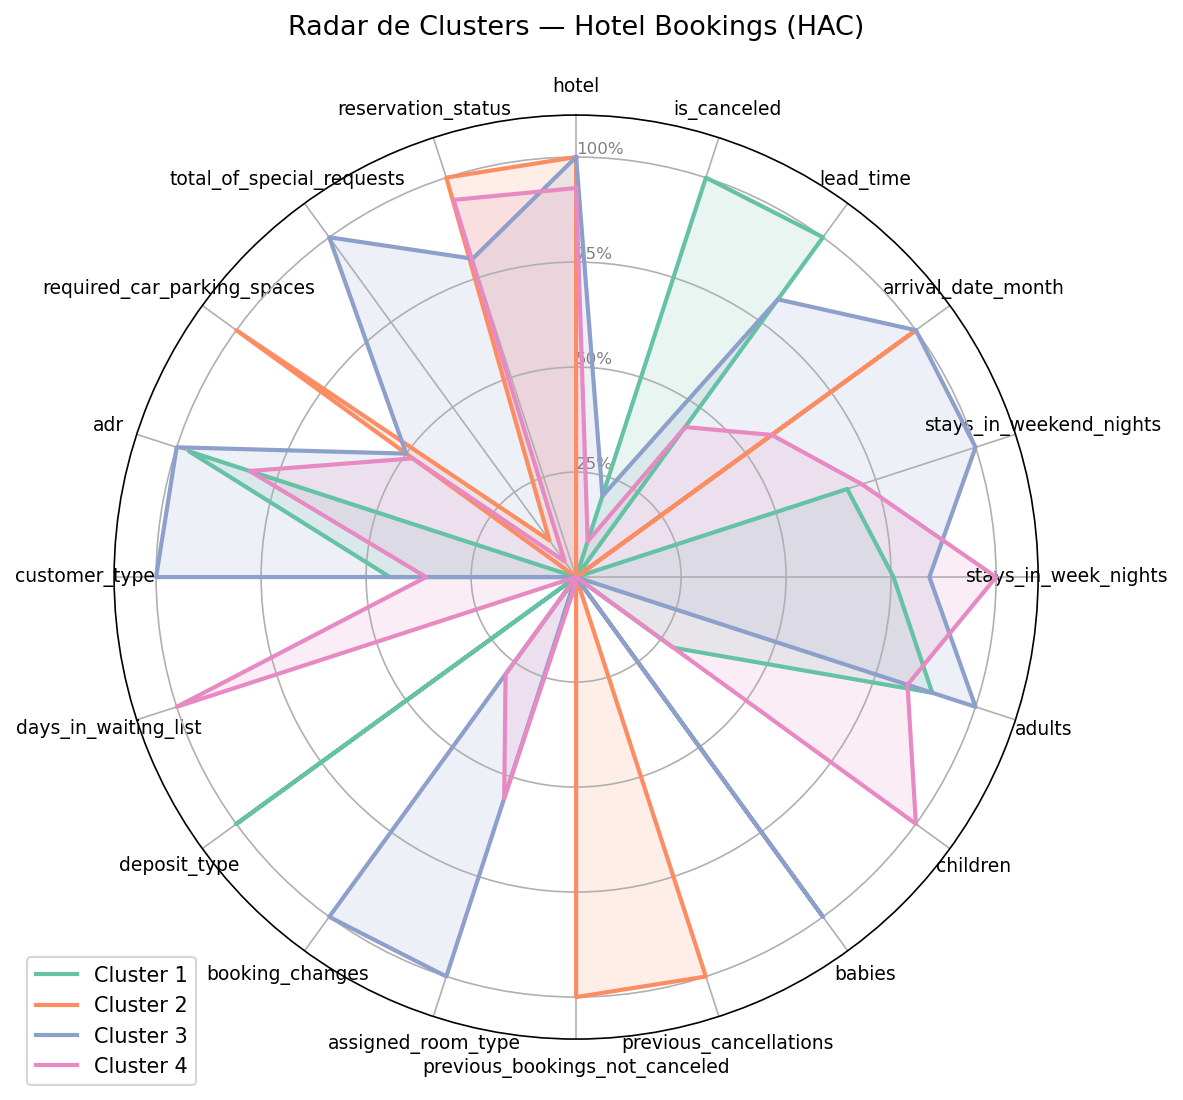

In [12]:
hac.plot_radar(titulo='Radar de Clusters — Hotel Bookings (HAC)')
plt.show()

## 6. Resumen estadístico por cluster

In [13]:
hac.resumen.style.background_gradient(cmap='Blues', axis=0).format('{:.2f}')

,hotel,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
cluster,,,,,,,,,,,,,,,,,,,,
1,0.40,0.99,156.58,3.12,1.08,2.84,1.89,0.07,0.00,0.00,0.00,1.11,0.10,0.17,0.00,2.09,121.55,0.00,0.63,0.01
2,1.00,0.00,3.40,3.60,0.40,1.40,1.00,0.00,0.00,1.00,10.00,0.80,0.20,0.00,0.00,2.00,54.40,0.40,0.80,1.00
3,1.00,0.20,128.60,3.60,1.40,3.00,2.00,0.00,1.00,0.00,0.00,3.80,1.60,0.00,0.00,2.20,123.71,0.20,2.20,0.80
4,0.96,0.09,71.02,3.40,1.12,3.30,1.83,0.26,0.00,0.00,0.13,2.46,0.53,0.00,0.69,2.07,111.04,0.19,0.70,0.95


## 7. Comparación de métodos de enlace

Columna 'hotel' codificada con el mapeo:
  City Hotel → 0
  Resort Hotel → 1
Columna 'arrival_date_month' codificada con el mapeo:
  April → 0
  August → 1
  February → 2
  January → 3
  July → 4
  June → 5
  March → 6
  May → 7
Columna 'assigned_room_type' codificada con el mapeo:
  A → 0
  B → 1
  C → 2
  D → 3
  E → 4
  F → 5
  G → 6
  H → 7
  I → 8
  K → 9
Columna 'deposit_type' codificada con el mapeo:
  No Deposit → 0
  Non Refund → 1
  Refundable → 2
Columna 'customer_type' codificada con el mapeo:
  Contract → 0
  Group → 1
  Transient → 2
  Transient-Party → 3
Columna 'reservation_status' codificada con el mapeo:
  Canceled → 0
  Check-Out → 1
  No-Show → 2
Valores nulos antes: 0 en 408 filas.
hotel                          0
is_canceled                    0
lead_time                      0
arrival_date_month             0
stays_in_weekend_nights        0
                              ..
customer_type                  0
adr                            0
required_car_parking_spa

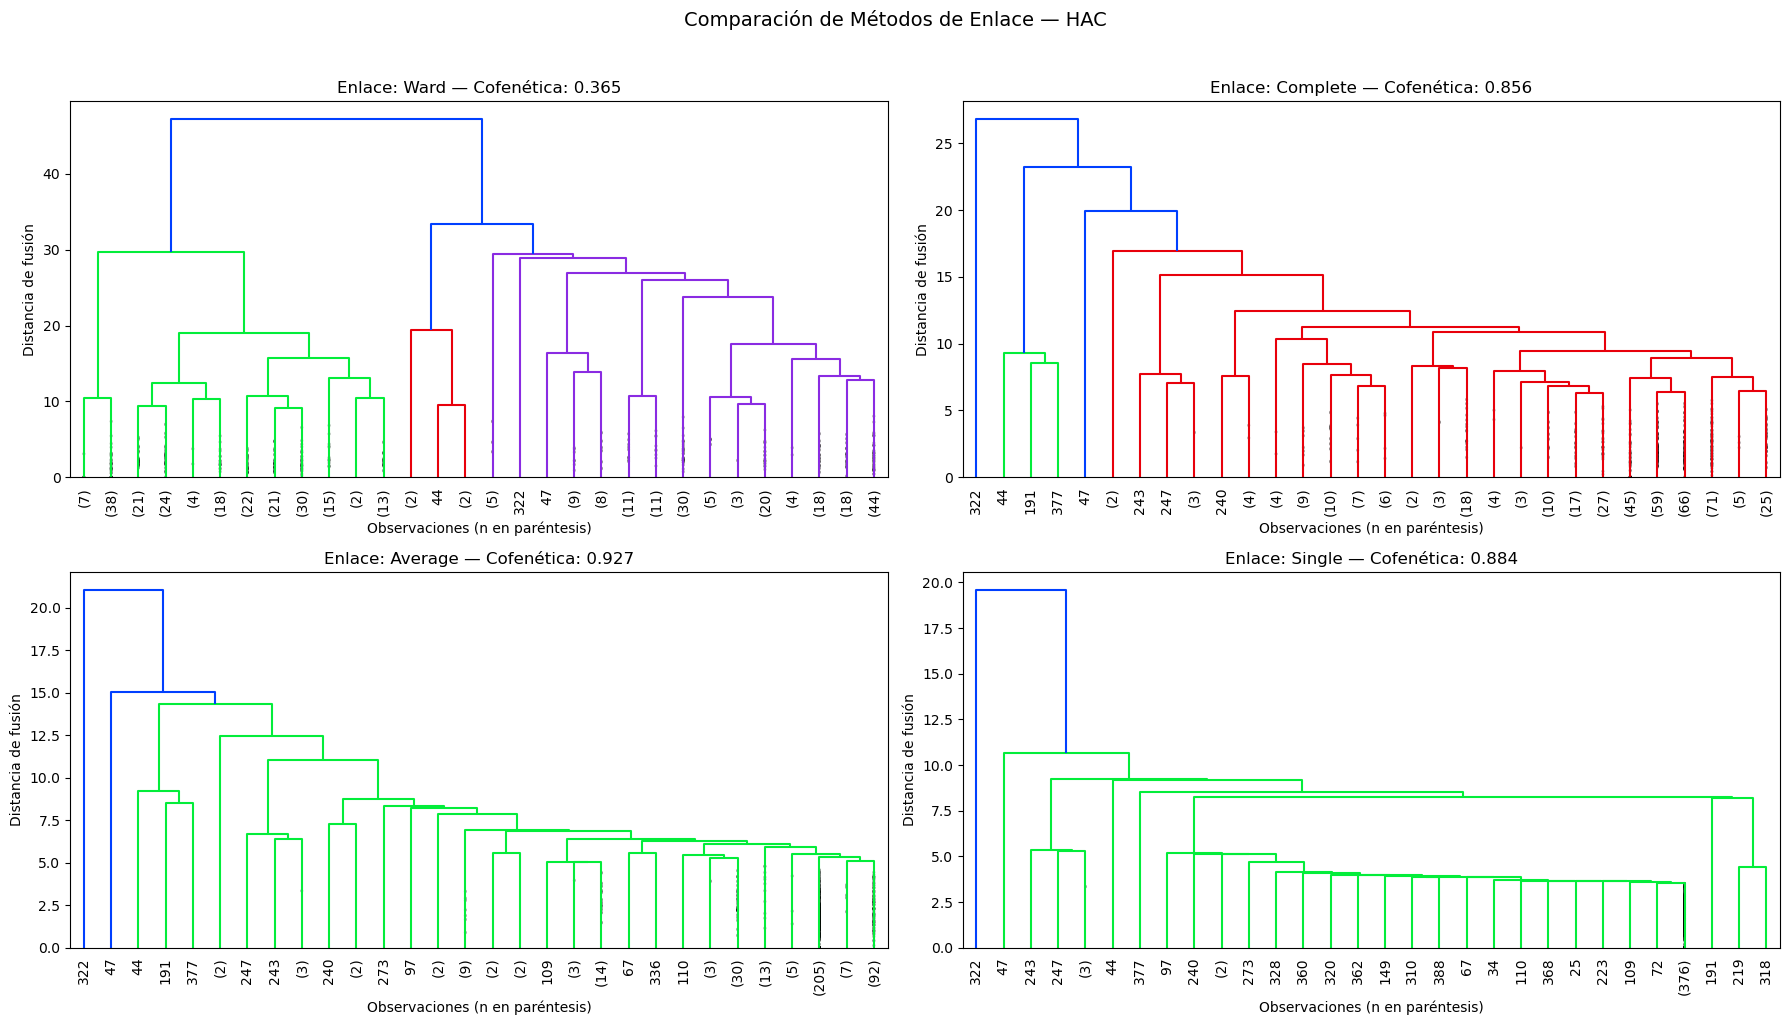

In [14]:
metodos = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for ax, metodo in zip(axes.ravel(), metodos):
    h = mf.HAC('../datasets/hotel_bookings.csv', 1, n_clusters=4, metodo=metodo)
    h.codificarCategorica('hotel')
    h.codificarCategorica('arrival_date_month')
    h.codificarCategorica('assigned_room_type')
    h.codificarCategorica('deposit_type', mapeo={'No Deposit': 0, 'Non Refund': 1, 'Refundable': 2})
    h.codificarCategorica('customer_type')
    h.codificarCategorica('reservation_status')
    h.eliminarNulos()
    h.analisisNumerico()
    h.ajustar()
    plt.sca(ax)
    h.plot_dendrograma(
        max_hojas=30,
        titulo=f'Enlace: {metodo.capitalize()} — Cofenética: {h.cophenet_corr:.3f}'
    )

plt.suptitle('Comparación de Métodos de Enlace — HAC', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Conclusiones

- El método **Ward** produce clusters equilibrados y obtiene la mejor correlación cofenética en datos tabulares.
- El **mapa de calor** revela los perfiles de cada cluster: grupos con alta tarifa (`adr`), largo tiempo de anticipación (`lead_time`), etc.
- Los **diagramas de dispersión** muestran qué tan separados están los clusters en el espacio de variables originales.
- La **correlación cofenética** es el indicador de calidad principal: cuanto más cercana a 1, mejor preserva la jerarquía las distancias reales.